# Simulation Method Validation and PSS Window Sticker

This notebook is analysis-only. Run `examples/IBM_QAOA/run_job.sh` or `examples/IBM_QAOA/run_job_small.sh` first to generate the IBM QAOA campaign artifacts, then load and analyze them here.


In [2]:
# Analysis imports
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from src.utils import (
    apply_shared_approx_axis,
    concat_summary,
    cross_strategy_envelope,
    curve_from_training_summary,
    curve_from_window_summary,
    curve_label,
    load_multi_strategy_summaries,
    plot_method_curves,
    prepare_monotone_curve,
    save_current_plot,
    shared_approx_ylim as compute_shared_approx_ylim,
    shared_approx_yticks as compute_shared_approx_yticks,
)
from src.simulation_validation import (
    build_binned_budget_dataset,
    build_strategy_budget_summary,
    run_stochastic_benchmark_pss,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)




In [3]:
# Analysis configuration
GRAPH_TYPE = 'heavy_hex'
NUM_NODES = 144
RESULT_TAG = 'heavy_hex_144_FA_PP_opt_p5_expanded'

BS_BOOTSTRAP_RANGE = range(10, 51, 10)
TRAIN_TEST_SPLIT_FRACTION = 0.5

OUTPUT_ROOT = Path(f'../results/pss_window_sticker/{RESULT_TAG}').resolve()
WINDOW_STICKER_DIR = OUTPUT_ROOT / 'window_sticker'
PLOT_DIR = OUTPUT_ROOT / 'notebook_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FRONTIER_PATH = OUTPUT_ROOT / 'pss_exp_raw_frontier.pkl'
FA_EXACT_PATH = OUTPUT_ROOT / 'fa_raw_points.pkl'
PT_EXACT_PATH = OUTPUT_ROOT / 'pt_raw_points.pkl'
TRAIN_SPECS_PATH = OUTPUT_ROOT / 'train_instance_specs.csv'
TEST_SPECS_PATH = OUTPUT_ROOT / 'test_instance_specs.csv'
CODEBOOK_PATH = OUTPUT_ROOT / 'ws_codebooks.json'
FRONTIER_PREVIEW_PATH = OUTPUT_ROOT / 'frontier_preview.csv'
FRONTIER_SUMMARY_PATH = OUTPUT_ROOT / 'frontier_group_summary.csv'


In [4]:
# Load campaign artifacts generated by the terminal script
required_paths = [FA_EXACT_PATH, CODEBOOK_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'Missing campaign artifacts. Run examples/IBM_QAOA/run_job.sh or '
        'examples/IBM_QAOA/run_job_small.sh first:\n' + missing
    )

exact_frames = [pd.read_pickle(FA_EXACT_PATH)]
if PT_EXACT_PATH.exists():
    exact_frames.append(pd.read_pickle(PT_EXACT_PATH))
exact_df = pd.concat(exact_frames, ignore_index=True)
ws_codebooks = json.loads(CODEBOOK_PATH.read_text(encoding='utf-8'))

stored_frontier_df = pd.read_pickle(FRONTIER_PATH) if FRONTIER_PATH.exists() else pd.DataFrame()
budget_grid_points = int(stored_frontier_df['T'].nunique()) if not stored_frontier_df.empty else 1000
frontier_df = build_binned_budget_dataset(
    exact_df,
    num_bins=budget_grid_points,
    budget_col='T_exact_proxy',
    scale='log',
)
strategy_reverse = {str(value): int(code) for code, value in ws_codebooks.get('strategy', {}).items()}
simulation_reverse = {str(value): int(code) for code, value in ws_codebooks.get('simulation', {}).items()}
frontier_df['strategy_code'] = frontier_df['strategy'].astype(str).map(strategy_reverse).astype(float)
frontier_df['simulation_code'] = frontier_df['simulation_method'].astype(str).map(simulation_reverse).astype(float)
frontier_df['train'] = frontier_df['split'].astype(str).map({'train': 1, 'test': 0}).astype(int)

train_specs_df = pd.read_csv(TRAIN_SPECS_PATH) if TRAIN_SPECS_PATH.exists() else pd.DataFrame()
test_specs_df = pd.read_csv(TEST_SPECS_PATH) if TEST_SPECS_PATH.exists() else pd.DataFrame()
frontier_preview_df = frontier_df.head(30).copy()
frontier_summary_df = frontier_df.groupby(['split', 'strategy'], as_index=False).agg(
    n_rows=('instance', 'size'),
    min_T=('T', 'min'),
    max_T=('T', 'max'),
    best_response=('BestApproximationRatio', 'max'),
)

print('Loaded campaign from:', OUTPUT_ROOT)
print('Exact rows:', len(exact_df))
print('Binned frontier rows:', len(frontier_df))
print('Budget bins used:', frontier_df['T'].nunique())
print('Strategies:', sorted(frontier_df['strategy'].dropna().unique()))
print('Splits:', sorted(frontier_df['split'].dropna().unique()))


Loaded campaign from: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
Exact rows: 12240
Binned frontier rows: 12240
Budget bins used: 159
Strategies: ['FA_PP_opt']
Splits: ['test', 'train']


In [5]:
# Quick artifact preview
display(train_specs_df.head(10))
display(test_specs_df.head(10))
display(frontier_preview_df)
display(frontier_summary_df)


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,100,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
1,heavy_hex,144,101,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
2,heavy_hex,144,102,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
3,heavy_hex,144,103,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
4,heavy_hex,144,104,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
5,heavy_hex,144,105,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
6,heavy_hex,144,106,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
7,heavy_hex,144,107,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
8,heavy_hex,144,108,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
9,heavy_hex,144,109,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,0,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
1,heavy_hex,144,1,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
2,heavy_hex,144,2,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
3,heavy_hex,144,3,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
4,heavy_hex,144,4,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
5,heavy_hex,144,5,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
6,heavy_hex,144,6,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
7,heavy_hex,144,7,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
8,heavy_hex,144,8,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
9,heavy_hex,144,9,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test


,graph_type,num_nodes,instance,instance_id,split,source,p,strategy,strategy_family,strategy_runtime_label,simulation_method,N,M,classical_setup_cost,training_cost,sampling_cost,T_exact,classical_setup_cost_proxy,training_cost_proxy,sampling_cost_proxy,T_exact_proxy,num_objective_evaluations,total_training_shots,runtime_train_wallclock,runtime_sample_wallclock,Q,counts,best_bitstring,best_found_value,BestApproximationRatio,Approximation_Ratio,budget_bin,budget_left,budget_right,T,resource,selected_exact_T,selected_exact_T_proxy,budget_distance,strategy_code,simulation_code,train
0,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,10,10,0.0,45.646189,0.944788,46.590976,0.0,0.000250,0.00050,0.000750,13,130,45.646189,0.944788,200,{'11011111000011010010101101001001001011101101...,0100000000001111111101001011000100110100011000...,49.618521,0.840171,0.840171,60,0.000747,0.000752,0.000749,0.000749,46.590976,0.000750,0.0,0.0,0.0,1
1,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,20,10,0.0,105.080708,1.225633,106.306341,0.0,0.000500,0.00050,0.001000,26,260,105.080708,1.225633,200,{'11011110011011001011110101011111011101000011...,0101100110001101001100111000111101011010001110...,55.486137,0.886811,0.886811,103,0.000995,0.001002,0.000999,0.000999,106.306341,0.001000,0.0,0.0,0.0,1
2,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,50,10,0.0,226.879621,0.922751,227.802371,0.0,0.001250,0.00050,0.001750,57,570,226.879621,0.922751,200,{'01011011101100101100011001001111110010010011...,0101101010101110101010111101001001101001001101...,47.743757,0.825269,0.825269,187,0.001745,0.001757,0.001751,0.001751,227.802371,0.001750,0.0,0.0,0.0,1
3,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,75,10,0.0,318.400722,0.885829,319.286551,0.0,0.001875,0.00050,0.002375,83,830,318.400722,0.885829,200,{'10111000000001000010010010110011110001110011...,0010011011110001010010000110001111000010001011...,47.365264,0.822260,0.822260,233,0.002374,0.002389,0.002381,0.002381,319.286551,0.002375,0.0,0.0,0.0,1
4,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,100,10,0.0,430.225393,1.112982,431.338375,0.0,0.002500,0.00050,0.003000,109,1090,430.225393,1.112982,200,{'11000100000001010001001111001101001111010110...,1101110000010001010101001110111011011101000010...,46.253817,0.813426,0.813426,268,0.002999,0.003019,0.003009,0.003009,431.338375,0.003000,0.0,0.0,0.0,1
5,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,10,50,0.0,56.370564,1.115766,57.486330,0.0,0.001250,0.00050,0.001750,13,650,56.370564,1.115766,200,{'01000000100110100110000000000010000001111001...,0011101111101110001000111010000011111001110011...,52.152567,0.860313,0.860313,187,0.001745,0.001757,0.001751,0.001751,57.486330,0.001750,0.0,0.0,0.0,1
6,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,20,50,0.0,114.965631,1.232290,116.197921,0.0,0.002500,0.00050,0.003000,26,1300,114.965631,1.232290,200,{'01000100000100000000110001100110100010000011...,1010010111101111001000110001000011001111110001...,51.123698,0.852135,0.852135,268,0.002999,0.003019,0.003009,0.003009,116.197921,0.003000,0.0,0.0,0.0,1
7,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,50,50,0.0,257.228827,1.218947,258.447774,0.0,0.006250,0.00050,0.006750,57,2850,257.228827,1.218947,200,{'00100000110001010101101111000010101100111000...,1100000110111000010001000111111000110111000100...,49.736662,0.841110,0.841110,389,0.006734,0.006779,0.006757,0.006757,258.447774,0.006750,0.0,0.0,0.0,1
8,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,75,50,0.0,363.494788,0.984605,364.479394,0.0,0.009375,0.00050,0.009875,83,4150,363.494788,0.984605,200,{'00111100011110001011111100110001000111000101...,1011101001110011100111111000001011110111001010...,50.906693,0.850410,0.850410,446,0.009857,0.009923,0.009890,0.009

,split,strategy,n_rows,min_T,max_T,best_response
0,test,FA_PP_opt,4080,0.000502,0.398665,0.906866
1,train,FA_PP_opt,8160,0.000502,0.398665,0.924205


In [6]:
# Inspect the available encoded metadata before running stochastic-benchmark
display(pd.DataFrame({
    'strategy_code': list(ws_codebooks.get('strategy', {}).keys()),
    'strategy_name': list(ws_codebooks.get('strategy', {}).values()),
}))
display(pd.DataFrame({
    'simulation_code': list(ws_codebooks.get('simulation', {}).keys()),
    'simulation_name': list(ws_codebooks.get('simulation', {}).values()),
}))


,strategy_code,strategy_name
0,0,FA_PP_opt


,simulation_code,simulation_name
0,0,MPSAer


,model,expression,alpha,beta,power_slope
0,through_origin,T_exact ≈ 2729.51 · T_proxy,2729.514674,0.00000,1.00000
1,affine,T_exact ≈ 1235.17 · T_proxy + 224.089,1235.173275,224.08913,1.00000
2,power_law,T_exact ≈ 643.329 · T_proxy^0.27952,643.328706,0.00000,0.27952


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/proxy_vs_exact_calibration.pdf and .png


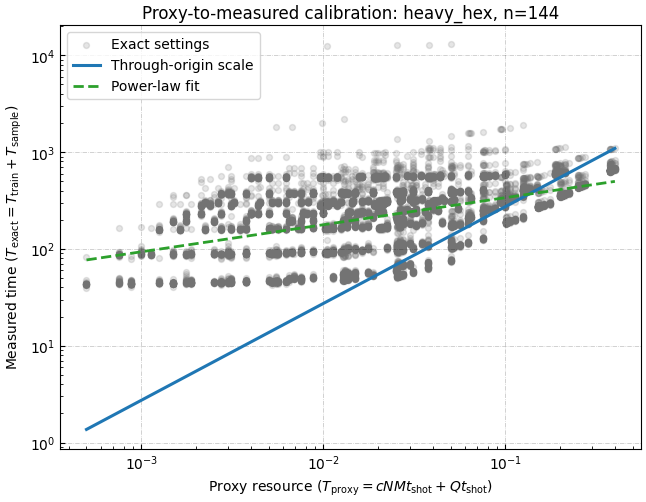

Recommended global scale to map proxy onto measured-time units:
  T_exact ≈ 2729.51 · T_proxy


In [7]:
# Proxy vs measured-time calibration
calibration_df = exact_df.loc[:, [
    'instance', 'split', 'N', 'M', 'Q',
    'T_exact_proxy', 'T_exact', 'training_cost', 'sampling_cost'
]].copy()
calibration_df = calibration_df.dropna(subset=['T_exact_proxy', 'T_exact'])
calibration_df = calibration_df[
    (pd.to_numeric(calibration_df['T_exact_proxy'], errors='coerce') > 0)
    & (pd.to_numeric(calibration_df['T_exact'], errors='coerce') > 0)
].copy()

proxy_values = calibration_df['T_exact_proxy'].to_numpy(dtype=float)
exact_values = calibration_df['T_exact'].to_numpy(dtype=float)

alpha_origin = float(np.dot(proxy_values, exact_values) / np.dot(proxy_values, proxy_values))
alpha_affine, beta_affine = np.polyfit(proxy_values, exact_values, deg=1)
log_slope, log_intercept = np.polyfit(np.log(proxy_values), np.log(exact_values), deg=1)
log_prefactor = float(np.exp(log_intercept))

proxy_grid = np.geomspace(proxy_values.min(), proxy_values.max(), 200)
origin_line = alpha_origin * proxy_grid
affine_line = alpha_affine * proxy_grid + beta_affine
power_line = log_prefactor * proxy_grid**log_slope

calibration_summary_df = pd.DataFrame([
    {
        'model': 'through_origin',
        'expression': f'T_exact ≈ {alpha_origin:.6g} · T_proxy',
        'alpha': alpha_origin,
        'beta': 0.0,
        'power_slope': 1.0,
    },
    {
        'model': 'affine',
        'expression': f'T_exact ≈ {alpha_affine:.6g} · T_proxy + {beta_affine:.6g}',
        'alpha': float(alpha_affine),
        'beta': float(beta_affine),
        'power_slope': 1.0,
    },
    {
        'model': 'power_law',
        'expression': f'T_exact ≈ {log_prefactor:.6g} · T_proxy^{log_slope:.6g}',
        'alpha': log_prefactor,
        'beta': 0.0,
        'power_slope': float(log_slope),
    },
])
calibration_summary_df.to_csv(OUTPUT_ROOT / 'proxy_exact_calibration_summary.csv', index=False)

display(calibration_summary_df)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(calibration_df['T_exact_proxy'], calibration_df['T_exact'], s=18, alpha=0.18, color='0.45', label='Exact settings')
plt.plot(proxy_grid, origin_line, color='tab:blue', linewidth=2.2, label='Through-origin scale')
plt.plot(proxy_grid, power_line, color='tab:green', linewidth=2.0, linestyle='--', label='Power-law fit')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Proxy resource $(T_{\mathrm{proxy}} = c N M t_{\mathrm{shot}} + Q t_{\mathrm{shot}})$')
plt.ylabel(r'Measured time $(T_{\mathrm{exact}} = T_{\mathrm{train}} + T_{\mathrm{sample}})$')
plt.title(f'Proxy-to-measured calibration: {GRAPH_TYPE}, n={NUM_NODES}')
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('proxy_vs_exact_calibration', PLOT_DIR)
plt.show()

print('Recommended global scale to map proxy onto measured-time units:')
print(f'  T_exact ≈ {alpha_origin:.6g} · T_proxy')


In [8]:
# Run stochastic-benchmark on the prepared IBM_QAOA exp_raw data
ws_results = run_stochastic_benchmark_pss(
    frontier_df,
    output_dir=WINDOW_STICKER_DIR,
    codebooks=ws_codebooks,
    response_col='BestApproximationRatio',
    resource_col='T',
    response_key='Response',
    bootstrap_range=BS_BOOTSTRAP_RANGE,
    train_test_split=TRAIN_TEST_SPLIT_FRACTION,
    clear_checkpoints=True,
)

virtual_best_df = ws_results['virtual_best_df']
projection_summary_df = ws_results['projection_summary_df']
window_sticker_summary_df = ws_results['window_sticker_summary_df']

print('Raw exp_raw files written:', len(ws_results['written_files']))
display(virtual_best_df)
display(window_sticker_summary_df)


  0%|          | 0/408 [00:00<?, ?it/s]/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, b

Raw exp_raw files written: 30


,resource,strategy_code,simulation_code,N,M,Q,p,index,response,response_lower,response_upper,count,strategy,simulation_method
0,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,0,0.814148,0.814148,0.814148,10,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,1,0.814148,0.814148,0.814148,10,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,13.0,10.0,140.0,5.0,2,0.834089,0.834089,0.834089,10,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,10.0,14.5,195.0,5.0,3,0.837202,0.837202,0.837202,10,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,10.0,14.5,195.0,5.0,4,0.837202,0.837202,0.837202,10,FA_PP_opt,MPSAer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0.388147,0.0,0.0,37.0,199.5,10000.0,5.0,278,0.886965,0.886965,0.886965,10,FA_PP_opt,MPSAer
279,0.388147,0.0,0.0,37.0,199.5,10000.0,5.0,279,0.886965,0.886965,0.886965,10,FA_PP_opt,MPSAer
280,0.398665,0.0,0.0,37.0,199.5,10000.0,5.0,280,0.886965,0.886965,0.886965,10,FA_PP_opt,MPSAer
281,0.398665,0.0,0.0,37.0,199.5,10000.0,5.0,281,0.886965,0.886965,0.886965,10,FA_PP_opt,MPSAer


,resource,strategy,simulation_method,N,M,Q,p,response,response_lower,response_upper
0,0.000502,FA_PP_opt,MPSAer,10.0,10.0,100.0,5.0,0.814148,0.814148,0.814148
1,0.000502,FA_PP_opt,MPSAer,10.0,10.0,100.0,5.0,0.814148,0.814148,0.814148
2,0.000749,FA_PP_opt,MPSAer,10.0,10.0,200.0,5.0,0.825749,0.825749,0.825749
3,0.000874,FA_PP_opt,MPSAer,10.0,10.0,250.0,5.0,0.830973,0.830973,0.830973
4,0.000874,FA_PP_opt,MPSAer,10.0,10.0,250.0,5.0,0.830973,0.830973,0.830973
...,...,...,...,...,...,...,...,...,...,...
278,0.388147,FA_PP_opt,MPSAer,150.0,1000.0,5000.0,5.0,0.850289,0.850289,0.850289
279,0.388147,FA_PP_opt,MPSAer,150.0,1000.0,5000.0,5.0,0.850289,0.850289,0.850289
280,0.398665,FA_PP_opt,MPSAer,150.0,1000.0,10000.0,5.0,0.854939,0.854939,0.854939
281,0.398665,FA_PP_opt,MPSAer,150.0,1000.0,10000.0,5.0,0.854939,0.854939,0.854939


,strategy,simulation_method,p,T,response_mean,response_std,response_min,response_max,N_mean,M_mean,Q_mean,training_cost_mean,sampling_cost_mean,training_cost_proxy_mean,sampling_cost_proxy_mean,T_exact_mean,T_exact_proxy_mean,n_instances,n_candidates
0,FA_PP_opt,MPSAer,5,0.000502,0.817931,0.036671,0.749938,0.871694,10.000000,10.000000,100.000000,45.087572,0.246766,0.000250,0.000250,45.334338,0.000500,20,20
1,FA_PP_opt,MPSAer,5,0.000749,0.822835,0.030943,0.762697,0.878621,15.000000,10.000000,150.000000,67.703290,0.572645,0.000375,0.000375,68.275935,0.000750,20,40
2,FA_PP_opt,MPSAer,5,0.000874,0.825717,0.033416,0.752243,0.887794,10.000000,17.500000,175.000000,45.794203,0.434334,0.000438,0.000438,46.228536,0.000875,20,40
3,FA_PP_opt,MPSAer,5,0.000999,0.826731,0.035798,0.740121,0.886811,20.000000,10.000000,200.000000,89.967441,0.916821,0.000500,0.000500,90.884263,0.001000,20,20
4,FA_PP_opt,MPSAer,5,0.001126,0.833690,0.029300,0.778801,0.891304,20.000000,10.000000,250.000000,90.955289,0.620011,0.000500,0.000625,91.575300,0.001125,20,20
5,FA_PP_opt,MPSAer,5,0.001254,0.820355,0.035841,0.752188,0.901959,25.000000,17.500000,175.000000,106.189803,0.438038,0.000813,0.000438,106.627841,0.001250,20,40
6,FA_PP_opt,MPSAer,5,0.001502,0.825553,0.032300,0.716439,0.900072,22.500000,23.750000,200.000000,98.702060,0.544759,0.001000,0.000500,99.246819,0.001500,20,80
7,FA_PP_opt,MPSAer,5,0.001627,0.820198,0.032051,0.763298,0.885242,40.000000,10.000000,250.000000,165.878773,0.616734,0.001000,0.000625,166.495507,0.001625,20,20
8,FA_PP_opt,MPSAer,5,0.001751,0.827964,0.034251,0.738944,0.893002,35.000000,20.000000,250.000000,142.592432,0.820909,0.001125,0.000625,143.413341,0.001750,20,80
9,FA_PP_opt,MPSAer,5,0.001872,0.834301,0.034761,0.732450,0.901959,13.333333,33.333333,333.333333,65.876445,0.840335,0.001042,0.000833,66.716781,0.001875,20,60


,resource,strategy_code,simulation_code,N,M,Q,p,response,n_instances,n_virtual_best_rows,strategy,simulation_method
0,0.000502,0.0,0.0,10.0,10.00,100.0,5.0,0.817931,20,20,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,10.0,10.00,100.0,5.0,0.817931,20,20,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,11.5,10.00,155.0,5.0,0.836947,20,20,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,0.841695,20,20,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,0.841695,20,20,FA_PP_opt,MPSAer
5,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,0.841695,20,20,FA_PP_opt,MPSAer
6,0.000999,0.0,0.0,13.5,12.25,187.5,5.0,0.846348,20,20,FA_PP_opt,MPSAer
7,0.000999,0.0,0.0,13.5,12.25,187.5,5.0,0.846348,20,20,FA_PP_opt,MPSAer
8,0.001126,0.0,0.0,15.0,10.00,220.0,5.0,0.849095,20,20,FA_PP_opt,MPSAer
9,0.001126,0.0,0.0,15.0,10.00,220.0,5.0,0.849095,20,20,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.000502,0.0,0.0,10.0,10.00,100.0,5.0,10.0,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,10.0,10.00,100.0,5.0,20.0,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,11.5,10.00,155.0,5.0,13.0,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,20.0,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,15.0,FA_PP_opt,MPSAer
5,0.000874,0.0,0.0,10.5,12.25,197.5,5.0,10.0,FA_PP_opt,MPSAer
6,0.000999,0.0,0.0,13.5,12.25,187.5,5.0,10.0,FA_PP_opt,MPSAer
7,0.000999,0.0,0.0,13.5,12.25,187.5,5.0,13.0,FA_PP_opt,MPSAer
8,0.001126,0.0,0.0,15.0,10.00,220.0,5.0,17.5,FA_PP_opt,MPSAer
9,0.001126,0.0,0.0,15.0,10.00,220.0,5.0,12.5,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.000502,0.0,0.0,12.860546,10.000000,100.000000,5.0,10.0,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,12.860546,10.000000,100.000000,5.0,20.0,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,15.393226,10.000000,100.000000,5.0,13.0,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,16.434874,10.000000,100.000000,5.0,20.0,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,16.434874,10.000000,100.000000,5.0,15.0,FA_PP_opt,MPSAer
5,0.000874,0.0,0.0,16.434874,10.000000,100.000000,5.0,10.0,FA_PP_opt,MPSAer
6,0.000999,0.0,0.0,17.370911,10.000000,121.784419,5.0,10.0,FA_PP_opt,MPSAer
7,0.000999,0.0,0.0,17.370911,10.000000,121.784419,5.0,13.0,FA_PP_opt,MPSAer
8,0.001126,0.0,0.0,18.236406,10.827051,147.456981,5.0,17.5,FA_PP_opt,MPSAer
9,0.001126,0.0,0.0,18.236406,10.827051,147.456981,5.0,12.5,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_lower,response_upper,strategy,simulation_method
0,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,0.817931,0.817931,0.817931,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,0.817931,0.817931,0.817931,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,10.0,10.0,200.0,5.0,0.831000,0.831000,0.831000,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,10.0,10.0,250.0,5.0,0.830997,0.830997,0.830997,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,10.0,10.0,250.0,5.0,0.830997,0.830997,0.830997,FA_PP_opt,MPSAer
5,0.000874,0.0,0.0,10.0,10.0,250.0,5.0,0.830997,0.830997,0.830997,FA_PP_opt,MPSAer
6,0.000999,0.0,0.0,20.0,10.0,200.0,5.0,0.826731,0.826731,0.826731,FA_PP_opt,MPSAer
7,0.000999,0.0,0.0,20.0,10.0,200.0,5.0,0.826731,0.826731,0.826731,FA_PP_opt,MPSAer
8,0.001126,0.0,0.0,20.0,10.0,250.0,5.0,0.833690,0.833690,0.833690,FA_PP_opt,MPSAer
9,0.001126,0.0,0.0,20.0,10.0,250.0,5.0,0.833690,0.833690,0.833690,FA_PP_opt,MPSAer


...

,resource,strategy_code,simulation_code,N,M,Q,p,response,response_lower,response_upper,strategy,simulation_method
0,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,0.814148,0.814148,0.814148,FA_PP_opt,MPSAer
1,0.000502,0.0,0.0,10.0,10.0,100.0,5.0,0.814148,0.814148,0.814148,FA_PP_opt,MPSAer
2,0.000749,0.0,0.0,20.0,10.0,100.0,5.0,0.814009,0.814009,0.814009,FA_PP_opt,MPSAer
3,0.000874,0.0,0.0,10.0,17.5,175.0,5.0,0.825235,0.825235,0.825235,FA_PP_opt,MPSAer
4,0.000874,0.0,0.0,10.0,17.5,175.0,5.0,0.825235,0.825235,0.825235,FA_PP_opt,MPSAer
5,0.000874,0.0,0.0,10.0,17.5,175.0,5.0,0.825235,0.825235,0.825235,FA_PP_opt,MPSAer
6,0.000999,0.0,0.0,20.0,10.0,200.0,5.0,0.809779,0.809779,0.809779,FA_PP_opt,MPSAer
7,0.000999,0.0,0.0,20.0,10.0,200.0,5.0,0.809779,0.809779,0.809779,FA_PP_opt,MPSAer
8,0.001126,0.0,0.0,20.0,10.0,250.0,5.0,0.818833,0.818833,0.818833,FA_PP_opt,MPSAer
9,0.001126,0.0,0.0,20.0,10.0,250.0,5.0,0.818833,0.818833,0.818833,FA_PP_opt,MPSAer


,parameter,expression,coeff_0,coeff_1,coeff_2
0,N,N(T) = exp(3.76 - 0.1469 log(T) - 0.04023 log(...,3.760015,-0.146905,-0.040226
1,M,M(T) = exp(6.723 + 0.4394 log(T) - 0.02945 log...,6.722623,0.439419,-0.029455
2,Q,Q(T) = exp(8.885 - 0.4256 log(T) - 0.1471 log(...,8.885146,-0.425559,-0.147127


,graph type,num nodes,fitted strategy,fitted p,fitted N,fitted M,fitted Q,fitted response
0,heavy_hex,144,FA_PP_opt,5.0,20.0,100.0,10000.0,0.859567


,dataset,n_rows,resource_min,resource_max
0,train frontier,8160,0.000502,0.398665
1,test frontier,4080,0.000502,0.398665
2,train virtual-best lookup,283,0.000502,0.398665
3,lookup prescription train,283,0.000502,0.398665
4,fitted prescription train,283,0.000502,0.398665
5,fitted prescription test,283,0.000502,0.398665


Actionable prescription equations:
  N(T) = exp(3.76 - 0.1469 log(T) - 0.04023 log(T)^2)
  M(T) = exp(6.723 + 0.4394 log(T) - 0.02945 log(T)^2)
  Q(T) = exp(8.885 - 0.4256 log(T) - 0.1471 log(T)^2)
Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/cost_vs_best_approximation_ratio.pdf and .png


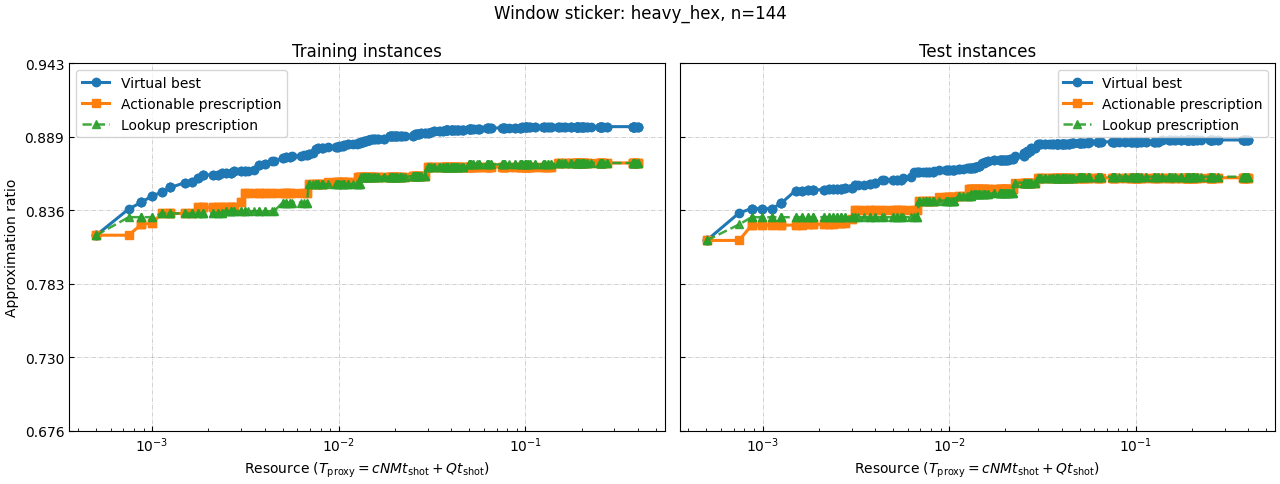

,strategy,T,ApproximationRatio
0,FA_PP_opt,0.000502,0.817931
1,FA_PP_opt,0.000749,0.822835
2,FA_PP_opt,0.000874,0.825717
3,FA_PP_opt,0.000999,0.826731
4,FA_PP_opt,0.001126,0.833690
...,...,...,...
154,FA_PP_opt,0.375388,0.824714
155,FA_PP_opt,0.377906,0.841977
156,FA_PP_opt,0.380441,0.851072
157,FA_PP_opt,0.388147,0.855452


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/per_method_cost_performance.pdf and .png


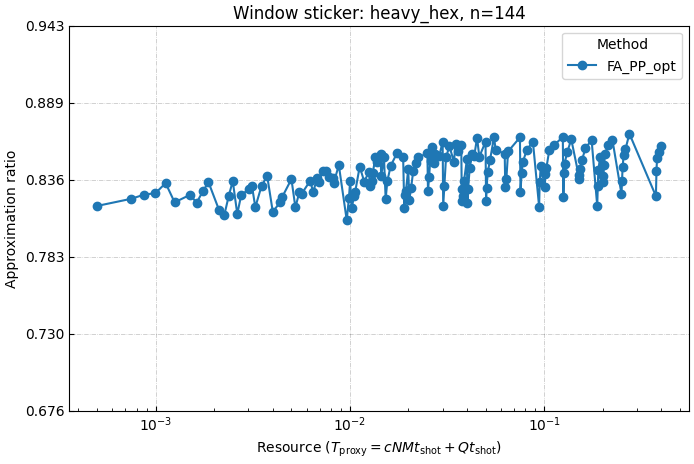

,resource,candidate_rows,candidate_unique_nmqs,N_min,N_max,M_min,M_max,Q_min,Q_max,T_exact_mean,T_exact_min,T_exact_max,T_proxy_mean,T_proxy_min,T_proxy_max,vb_response,vb_N_mean,vb_M_mean,vb_Q_mean,strategy,simulation_method,p,lookup_N,lookup_M,lookup_Q,fitted_N,fitted_M,fitted_Q,lookup_response_train,fitted_response_train
0,0.000502,20,1,10,10,10,10,100,100,45.334338,39.898058,82.882875,0.000500,0.000500,0.000500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000749,40,2,10,20,10,10,100,200,68.275935,42.986780,162.509627,0.000750,0.000750,0.000750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000874,40,2,10,10,10,25,100,250,46.228536,40.256115,83.499841,0.000875,0.000875,0.000875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000999,20,1,20,20,10,10,200,200,90.884263,85.889503,106.306341,0.001000,0.001000,0.001000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.001126,20,1,20,20,10,10,250,250,91.575300,83.469028,163.147796,0.001125,0.001125,0.001125,0.849095,15.00,10.00,220.0,FA_PP_opt,MPSAer,5.0,15.00,10.00,220.0,18.236406,10.827051,147.456981,0.833690,0.833690
5,0.001254,40,2,10,40,10,25,100,250,106.627841,43.820160,291.061994,0.001250,0.001250,0.001250,0.852527,14.00,13.75,225.0,FA_PP_opt,MPSAer,5.0,14.00,13.75,225.0,19.023261,11.839976,174.162778,0.833385,0.807326
6,0.001502,80,4,10,50,10,50,100,500,99.246819,40.852877,339.876409,0.001500,0.001500,0.001500,0.856031,15.00,17.00,230.0,FA_PP_opt,MPSAer,5.0,15.00,17.00,230.0,20.386234,13.747723,228.891621,0.820981,0.820981
7,0.001627,20,1,40,40,10,10,250,250,166.495507,151.379143,291.532139,0.001625,0.001625,0.001625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.001751,80,4,10,60,10,50,100,500,143.413341,43.525760,359.047993,0.001750,0.001750,0.001750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.001872,60,3,10,20,25,50,250,500,66.716781,43.668459,288.406015,0.001875,0.001875,0.001875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/mnq_settings_by_budget.pdf and .png


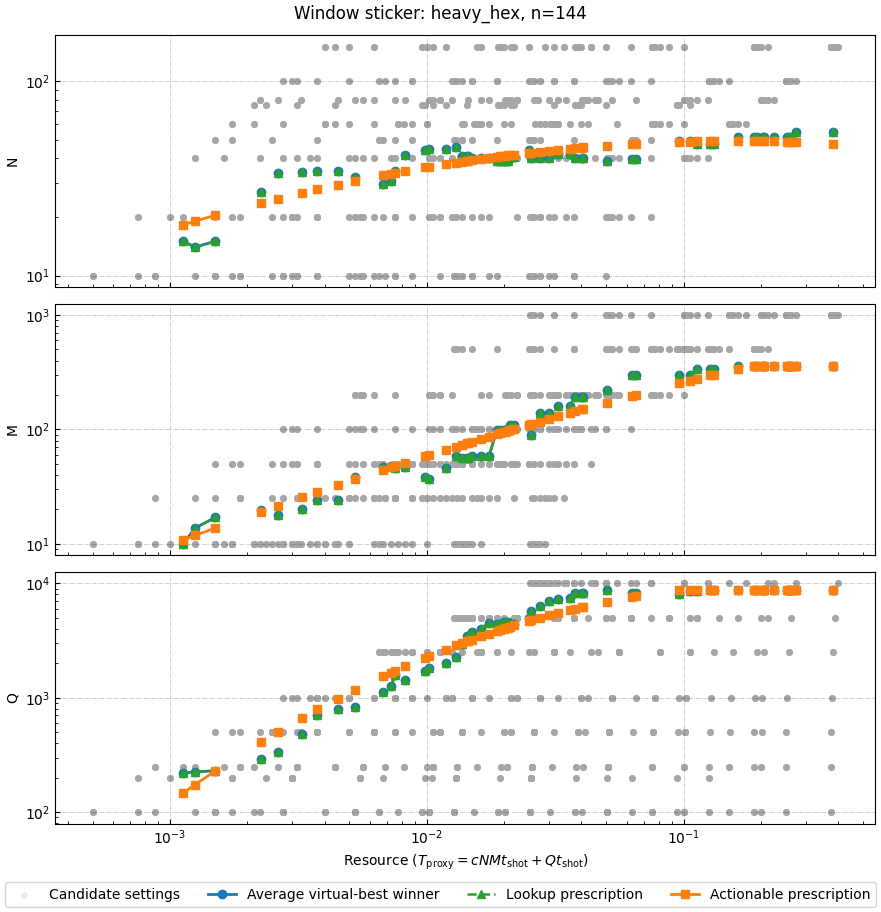

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/monotone_envelope_comparison.pdf and .png


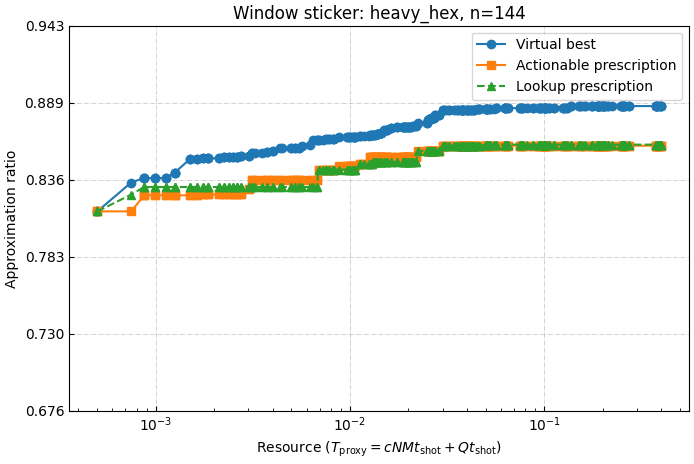

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/training_quality_by_budget.pdf and .png


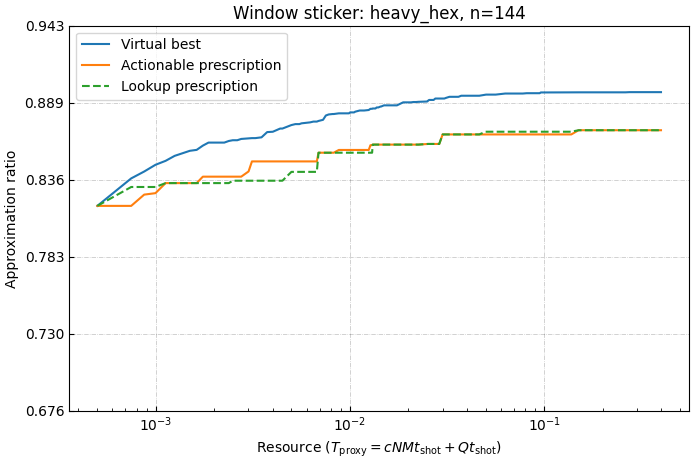

In [9]:
# Final summaries and plots
strategy_budget_df = build_strategy_budget_summary(frontier_df, split='train')
vb_train_lookup_df = ws_results['vb_train_lookup_df'].copy()
lookup_recipe_train_df = ws_results['recipe_train_df'].copy()
lookup_train_eval_df = ws_results['actionable_train_eval_df'].copy()
fitted_recipe_train_df = ws_results['fitted_recipe_df'].copy()
fitted_train_eval_df = ws_results['fitted_train_eval_df'].copy()
fitted_test_eval_df = ws_results['fitted_test_eval_df'].copy()
fitted_recipe_model_df = ws_results['fitted_recipe_model_df'].copy()
lookup_test_eval_df = window_sticker_summary_df.copy()

best_fitted_df = fitted_test_eval_df.sort_values(['response', 'resource'], ascending=[False, True]).reset_index(drop=True)

recommendation_summary = pd.DataFrame([
    {
        'graph type': GRAPH_TYPE,
        'num nodes': NUM_NODES,
        'fitted strategy': best_fitted_df.iloc[0]['strategy'] if not best_fitted_df.empty else None,
        'fitted p': best_fitted_df.iloc[0]['p'] if not best_fitted_df.empty else None,
        'fitted N': best_fitted_df.iloc[0]['N'] if not best_fitted_df.empty else None,
        'fitted M': best_fitted_df.iloc[0]['M'] if not best_fitted_df.empty else None,
        'fitted Q': best_fitted_df.iloc[0]['Q'] if not best_fitted_df.empty else None,
        'fitted response': best_fitted_df.iloc[0]['response'] if not best_fitted_df.empty else None,
    }
])

display(strategy_budget_df.head(20))
display(vb_train_lookup_df.head(20))
display(lookup_recipe_train_df.head(20))
display(fitted_recipe_train_df.head(20))
display(lookup_train_eval_df.head(20))
display(fitted_train_eval_df.head(20))
display(fitted_test_eval_df.head(20))
display(fitted_recipe_model_df)
display(recommendation_summary)

resource_support_debug_df = pd.DataFrame([
    {
        'dataset': 'train frontier',
        'n_rows': len(frontier_df[frontier_df['split'].astype(str).eq('train')]),
        'resource_min': frontier_df.loc[frontier_df['split'].astype(str).eq('train'), 'T'].min(),
        'resource_max': frontier_df.loc[frontier_df['split'].astype(str).eq('train'), 'T'].max(),
    },
    {
        'dataset': 'test frontier',
        'n_rows': len(frontier_df[frontier_df['split'].astype(str).eq('test')]),
        'resource_min': frontier_df.loc[frontier_df['split'].astype(str).eq('test'), 'T'].min(),
        'resource_max': frontier_df.loc[frontier_df['split'].astype(str).eq('test'), 'T'].max(),
    },
    {
        'dataset': 'train virtual-best lookup',
        'n_rows': len(vb_train_lookup_df),
        'resource_min': vb_train_lookup_df['resource'].min() if not vb_train_lookup_df.empty else None,
        'resource_max': vb_train_lookup_df['resource'].max() if not vb_train_lookup_df.empty else None,
    },
    {
        'dataset': 'lookup prescription train',
        'n_rows': len(lookup_recipe_train_df),
        'resource_min': lookup_recipe_train_df['resource'].min() if not lookup_recipe_train_df.empty else None,
        'resource_max': lookup_recipe_train_df['resource'].max() if not lookup_recipe_train_df.empty else None,
    },
    {
        'dataset': 'fitted prescription train',
        'n_rows': len(fitted_recipe_train_df),
        'resource_min': fitted_recipe_train_df['resource'].min() if not fitted_recipe_train_df.empty else None,
        'resource_max': fitted_recipe_train_df['resource'].max() if not fitted_recipe_train_df.empty else None,
    },
    {
        'dataset': 'fitted prescription test',
        'n_rows': len(fitted_test_eval_df),
        'resource_min': fitted_test_eval_df['resource'].min() if not fitted_test_eval_df.empty else None,
        'resource_max': fitted_test_eval_df['resource'].max() if not fitted_test_eval_df.empty else None,
    },
])
display(resource_support_debug_df)

if not fitted_recipe_model_df.empty:
    print('Actionable prescription equations:')
    for expression in fitted_recipe_model_df['expression'].dropna().tolist():
        print('  ' + expression)

shared_approx_ylim = compute_shared_approx_ylim(
    virtual_best_df.get('response'),
    fitted_test_eval_df.get('response'),
    lookup_test_eval_df.get('response'),
    vb_train_lookup_df.get('response'),
    lookup_train_eval_df.get('response'),
    fitted_train_eval_df.get('response'),
    strategy_budget_df.get('response_mean'),
    frontier_df.get('BestApproximationRatio'),
)
shared_approx_yticks = compute_shared_approx_yticks(shared_approx_ylim)

fitted_curve_label = curve_label(fitted_test_eval_df, 'Actionable prescription')
lookup_curve_label = curve_label(lookup_test_eval_df, 'Lookup prescription')

train_virtual_best_monotone_df = prepare_monotone_curve(vb_train_lookup_df)
lookup_train_monotone_df = prepare_monotone_curve(lookup_train_eval_df)
fitted_train_monotone_df = prepare_monotone_curve(fitted_train_eval_df)
test_virtual_best_monotone_df = prepare_monotone_curve(virtual_best_df)
lookup_test_monotone_df = prepare_monotone_curve(lookup_test_eval_df)
fitted_test_monotone_df = prepare_monotone_curve(fitted_test_eval_df)

main_title = f'Window sticker: {GRAPH_TYPE}, n={NUM_NODES}'
xlabel = r'Resource $(T_{\mathrm{proxy}} = c N M t_{\mathrm{shot}} + Q t_{\mathrm{shot}})$'
ylabel = 'Approximation ratio'

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_specs = [
    (axes[0], train_virtual_best_monotone_df, fitted_train_monotone_df, lookup_train_monotone_df, 'Training instances'),
    (axes[1], test_virtual_best_monotone_df, fitted_test_monotone_df, lookup_test_monotone_df, 'Test instances'),
]
for ax, vb_curve, fitted_curve, lookup_curve, title in plot_specs:
    ax.plot(vb_curve['resource'], vb_curve['response_monotone'], color='tab:blue', marker='o', linewidth=2.2, label='Virtual best')
    ax.plot(fitted_curve['resource'], fitted_curve['response_monotone'], color='tab:orange', marker='s', linewidth=2.2, label='Actionable prescription')
    ax.plot(lookup_curve['resource'], lookup_curve['response_monotone'], color='tab:green', marker='^', linewidth=1.8, linestyle='--', alpha=0.9, label='Lookup prescription')
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    plt.sca(ax)
    apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
    ax.legend()
axes[0].set_ylabel(ylabel)
fig.suptitle(main_title)
fig.tight_layout()
save_current_plot('cost_vs_best_approximation_ratio', PLOT_DIR)
plt.show()

per_method_curve_df = strategy_budget_df.loc[:, ['strategy', 'T', 'response_mean']].rename(columns={'response_mean': 'ApproximationRatio'})
display(per_method_curve_df)
plt.figure(figsize=(8, 5))
for strategy_name, group in per_method_curve_df.groupby('strategy'):
    plt.plot(group['T'], group['ApproximationRatio'], marker='o', label=strategy_name)
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend(title='Method')
save_current_plot('per_method_cost_performance', PLOT_DIR)
plt.show()

train_candidate_summary_df = (
    frontier_df[frontier_df['split'].astype(str).eq('train')]
    .groupby('T', as_index=False)
    .agg(
        candidate_rows=('instance', 'size'),
        candidate_unique_nmqs=('Q', lambda s: len({tuple(vals) for vals in frontier_df.loc[s.index, ['N', 'M', 'Q']].itertuples(index=False, name=None)})),
        N_min=('N', 'min'), N_max=('N', 'max'),
        M_min=('M', 'min'), M_max=('M', 'max'),
        Q_min=('Q', 'min'), Q_max=('Q', 'max'),
        T_exact_mean=('selected_exact_T', 'mean'),
        T_exact_min=('selected_exact_T', 'min'),
        T_exact_max=('selected_exact_T', 'max'),
        T_proxy_mean=('selected_exact_T_proxy', 'mean'),
        T_proxy_min=('selected_exact_T_proxy', 'min'),
        T_proxy_max=('selected_exact_T_proxy', 'max'),
    )
    .rename(columns={'T': 'resource'})
)

budget_recommendation_table_df = (
    train_candidate_summary_df
    .merge(vb_train_lookup_df.loc[:, [c for c in ['resource', 'response', 'N', 'M', 'Q'] if c in vb_train_lookup_df.columns]].rename(columns={'response':'vb_response','N':'vb_N_mean','M':'vb_M_mean','Q':'vb_Q_mean'}), on='resource', how='left')
    .merge(lookup_recipe_train_df.loc[:, [c for c in ['resource', 'strategy', 'simulation_method', 'p', 'N', 'M', 'Q'] if c in lookup_recipe_train_df.columns]].rename(columns={'N':'lookup_N','M':'lookup_M','Q':'lookup_Q'}), on='resource', how='left')
    .merge(fitted_recipe_train_df.loc[:, [c for c in ['resource', 'N', 'M', 'Q'] if c in fitted_recipe_train_df.columns]].rename(columns={'N':'fitted_N','M':'fitted_M','Q':'fitted_Q'}), on='resource', how='left')
    .merge(lookup_train_eval_df.loc[:, [c for c in ['resource', 'response'] if c in lookup_train_eval_df.columns]].rename(columns={'response':'lookup_response_train'}), on='resource', how='left')
    .merge(fitted_train_eval_df.loc[:, [c for c in ['resource', 'response'] if c in fitted_train_eval_df.columns]].rename(columns={'response':'fitted_response_train'}), on='resource', how='left')
    .sort_values('resource')
    .reset_index(drop=True)
)

budget_recommendation_table_df.to_csv(OUTPUT_ROOT / 'budget_bin_recommendation_table_train.csv', index=False)
display(budget_recommendation_table_df.head(20))

settings_points_df = exact_df[exact_df['split'].astype(str).eq('train')].copy().dropna(subset=['T_exact_proxy', 'N', 'M', 'Q'])
if not settings_points_df.empty:
    fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
    parameter_specs = [
        ('N', 'vb_N_mean', 'lookup_N', 'fitted_N', 'N'),
        ('M', 'vb_M_mean', 'lookup_M', 'fitted_M', 'M'),
        ('Q', 'vb_Q_mean', 'lookup_Q', 'fitted_Q', 'Q'),
    ]
    for ax, (raw_col, vb_col, lookup_col, fitted_col, label) in zip(axes, parameter_specs):
        ax.scatter(settings_points_df['T_exact_proxy'], settings_points_df[raw_col], s=14, alpha=0.18, color='0.65', label='Candidate settings')
        ax.plot(budget_recommendation_table_df['resource'], budget_recommendation_table_df[vb_col], color='tab:blue', marker='o', linewidth=2.0, label='Average virtual-best winner')
        ax.plot(budget_recommendation_table_df['resource'], budget_recommendation_table_df[lookup_col], color='tab:green', marker='^', linewidth=1.8, linestyle='--', label='Lookup prescription')
        ax.plot(budget_recommendation_table_df['resource'], budget_recommendation_table_df[fitted_col], color='tab:orange', marker='s', linewidth=2.0, label='Actionable prescription')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylabel(label)
        ax.grid(alpha=0.25)
    axes[-1].set_xlabel(xlabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(main_title)
    fig.tight_layout()
    save_current_plot('mnq_settings_by_budget', PLOT_DIR)
    plt.show()

plt.figure(figsize=(8, 5))
plt.plot(test_virtual_best_monotone_df['resource'], test_virtual_best_monotone_df['response_monotone'], marker='o', label='Virtual best')
plt.plot(fitted_test_monotone_df['resource'], fitted_test_monotone_df['response_monotone'], marker='s', label='Actionable prescription')
plt.plot(lookup_test_monotone_df['resource'], lookup_test_monotone_df['response_monotone'], marker='^', linestyle='--', label='Lookup prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('monotone_envelope_comparison', PLOT_DIR)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_virtual_best_monotone_df['resource'], train_virtual_best_monotone_df['response_monotone'], label='Virtual best')
plt.plot(fitted_train_monotone_df['resource'], fitted_train_monotone_df['response_monotone'], label='Actionable prescription')
plt.plot(lookup_train_monotone_df['resource'], lookup_train_monotone_df['response_monotone'], linestyle='--', label='Lookup prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('training_quality_by_budget', PLOT_DIR)
plt.show()


## Multi-Strategy Window Sticker Comparison

This section is written to work before and after the remaining strategies are run. Today, `MULTI_STRATEGY_RESULT_TAGS` can contain only the current `FA_PP_opt` result tag. Later, add one result tag per strategy root and rerun this section to get the Figure-6-style comparison: one actionable curve per strategy plus the envelope over strategies.


Loaded strategy roots:
  FA_PP_opt (MPSAer, p=5): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
Hyperparameter lookup rows: 1000


,method_label,strategy,simulation_method,p,T,response_mean,N_mean,M_mean,Q_mean,T_exact_proxy_mean,n_instances,n_candidates
0,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000500,0.817931,10.0,10.0,100.0,0.0005,20,20
1,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000503,0.817931,10.0,10.0,100.0,0.0005,20,20
2,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000507,0.817931,10.0,10.0,100.0,0.0005,20,20
3,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000510,0.817931,10.0,10.0,100.0,0.0005,20,20
4,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000514,0.817931,10.0,10.0,100.0,0.0005,20,20
5,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000517,0.817931,10.0,10.0,100.0,0.0005,20,20
6,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000520,0.817931,10.0,10.0,100.0,0.0005,20,20
7,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000524,0.817931,10.0,10.0,100.0,0.0005,20,20
8,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000527,0.817931,10.0,10.0,100.0,0.0005,20,20
9,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000531,0.817931,10.0,10.0,100.0,0.0005,20,20


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/multi_strategy_training_curves_envelope.pdf and .png


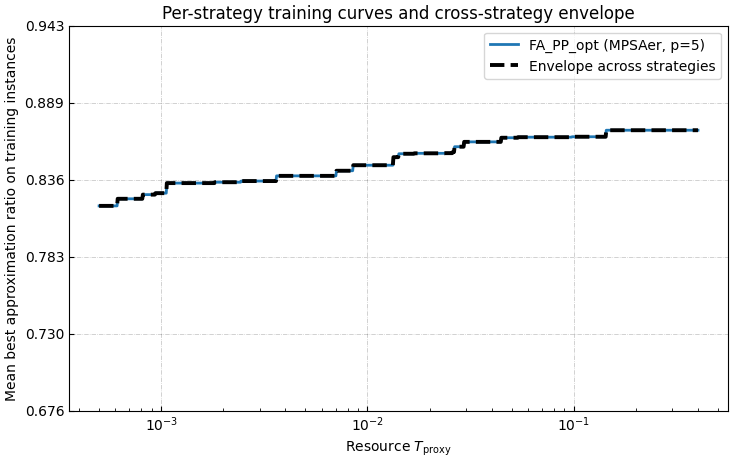

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/multi_strategy_actionable_projection_envelope.pdf and .png


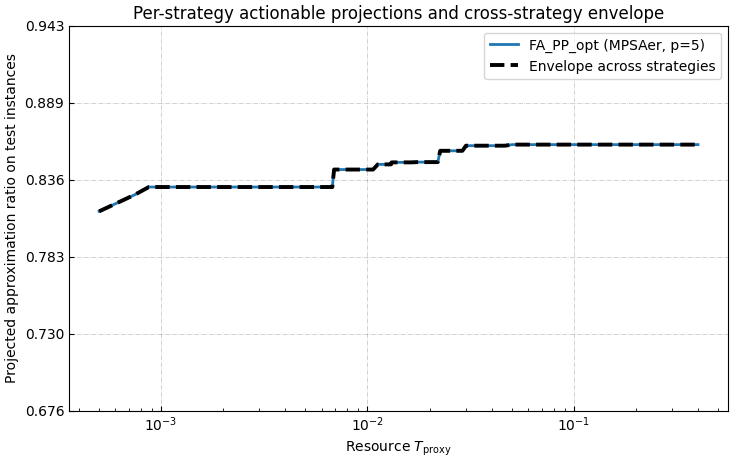

In [10]:
# Multi-strategy actionable PSS comparison
# Add future strategy result tags here after those campaigns finish.
MULTI_STRATEGY_RESULT_TAGS = [
    RESULT_TAG,
    # 'heavy_hex_144_LR_PP_opt_p5_expanded',
    # 'heavy_hex_144_FA_MPSAer_opt_p5_expanded',
    # 'heavy_hex_144_LR_MPSAer_opt_p5_expanded',
    # 'heavy_hex_144_PT_PP_AAA_p5_expanded',
]

PSS_RESULTS_BASE = OUTPUT_ROOT.parent

multi_strategy_summaries = load_multi_strategy_summaries(MULTI_STRATEGY_RESULT_TAGS, PSS_RESULTS_BASE)
print('Loaded strategy roots:')
for item in multi_strategy_summaries:
    print(f"  {item['method_label']}: {item['root']}")

multi_strategy_budget_df = concat_summary(multi_strategy_summaries, 'strategy_budget')
multi_actionable_lookup_df = concat_summary(multi_strategy_summaries, 'actionable_lookup')
multi_actionable_fit_df = concat_summary(multi_strategy_summaries, 'actionable_fit')
multi_window_sticker_df = concat_summary(multi_strategy_summaries, 'window_sticker')

training_strategy_curve_df = curve_from_training_summary(multi_strategy_budget_df)
training_strategy_envelope_df = cross_strategy_envelope(training_strategy_curve_df, 'T')

actionable_projection_curve_df = curve_from_window_summary(multi_window_sticker_df)
actionable_projection_envelope_df = cross_strategy_envelope(actionable_projection_curve_df, 'resource')

# This table is the direct answer to: which hyperparameters define the strategy curve at each budget?
hyperparameter_lookup_cols = [
    col for col in [
        'method_label', 'strategy', 'simulation_method', 'p', 'T', 'response_mean',
        'N_mean', 'M_mean', 'Q_mean', 'T_exact_proxy_mean', 'n_instances', 'n_candidates',
    ]
    if col in multi_actionable_lookup_df.columns
]
hyperparameter_lookup_df = multi_actionable_lookup_df.loc[:, hyperparameter_lookup_cols].copy() if hyperparameter_lookup_cols else pd.DataFrame()

if not hyperparameter_lookup_df.empty:
    hyperparameter_lookup_df.to_csv(OUTPUT_ROOT / 'multi_strategy_hyperparameter_lookup.csv', index=False)
if not training_strategy_envelope_df.empty:
    training_strategy_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_training_envelope.csv', index=False)
if not actionable_projection_envelope_df.empty:
    actionable_projection_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_actionable_projection_envelope.csv', index=False)

print('Hyperparameter lookup rows:', len(hyperparameter_lookup_df))
display(hyperparameter_lookup_df.head(20))

plot_method_curves(
    training_strategy_curve_df,
    training_strategy_envelope_df,
    resource_col='T',
    ylabel='Mean best approximation ratio on training instances',
    title='Per-strategy training curves and cross-strategy envelope',
    filename='multi_strategy_training_curves_envelope',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
)

plot_method_curves(
    actionable_projection_curve_df,
    actionable_projection_envelope_df,
    resource_col='resource',
    ylabel='Projected approximation ratio on test instances',
    title='Per-strategy actionable projections and cross-strategy envelope',
    filename='multi_strategy_actionable_projection_envelope',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
)


